# Calibration & abstention

Reproduces the **calibration / abstention** panels of the DeepCell Types paper.
These diagnostics characterize the **From Scratch max-softmax** confidence and the
cell-type **abstention** the model applies (a per-cell flag precomputed in the
released predictions):

- **Reliability diagram (Supp. Fig. 5f)** — 12-bin, ±5 pp envelope, plus ECE.
- **Confidence by correctness (Supp. Fig. 5g)** — confidence histograms split by
  hierarchical correctness, with the abstention threshold overlaid.

Abstained cells are flagged in the released predictions; the panels read that
flag directly. Figures use a consistent publication figure style via
`dct_figures.style`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared config

Cell-type ordering and the lineage taxonomy come from `dct_figures`: the
51-class canonical order in `scoring.CT2IDX` and the lineage taxonomy from
`data/lineage_mapping.yaml`.

We load the From Scratch test predictions once and derive per-cell max-softmax
confidence, the argmax prediction, and a hierarchical-correctness flag
(`scoring.CELL_TYPE_HIERARCHY`). The per-cell `tissue`, `modality`, and
`abstained` columns are precomputed in the released predictions.

In [2]:
import yaml
from dct_figures.scoring import CELL_TYPE_HIERARCHY, adjust_conf_mat_hierarchy

ct2idx = scoring.CT2IDX
idx2ct = {v: k for k, v in ct2idx.items()}
n_classes = len(ct2idx)

with open(paths.DATA_ROOT / 'lineage_mapping.yaml') as f:
    lineage_map = yaml.safe_load(f)

DCT_CSV = paths.OUTPUT / 'deepcelltypes_test_prediction.csv'
_df_raw = pd.read_csv(paths.need(DCT_CSV))
class_cols = [c for c in _df_raw.columns if c in ct2idx]
_probs = _df_raw[class_cols].to_numpy(dtype=np.float32)
_pred_i = _probs.argmax(axis=1)
max_prob = _probs[np.arange(_probs.shape[0]), _pred_i]
pred_labels = np.array(class_cols)[_pred_i]
true_labels = _df_raw['cell_type_actual'].to_numpy(dtype=str)

# tissue, modality, and the abstention flag are precomputed columns.
groups = (_df_raw['tissue'].astype(str) + '|' + _df_raw['modality'].astype(str)).to_numpy()
abstained = _df_raw['abstained'].to_numpy(dtype=bool)


def _hier_correct(true_l, pred_l):
    correct = (true_l == pred_l)
    for parent, children in CELL_TYPE_HIERARCHY.items():
        forgive = (true_l == parent) & np.isin(pred_l, list(children))
        correct = correct | forgive
    return correct

correct = _hier_correct(true_labels, pred_labels)
print(f'{len(max_prob):,} cells | {len(np.unique(groups))} (tissue, modality) groups '
      f'| hier-correct = {correct.mean()*100:.2f}% | abstained = {abstained.mean()*100:.1f}%')

486,705 cells | 11 (tissue, modality) groups | hier-correct = 89.77% | abstained = 17.9%


### Abstention threshold

The model's abstention decision is precomputed (the `abstained` column). For
the overlay below we summarize it as a single confidence threshold: per
(tissue, modality) group, the lowest-confidence cell that is still kept, taken
at the median across groups.

In [3]:
# The abstention decision is precomputed; recover a single display threshold
# from it: per (tissue, modality) group, the lowest kept-cell confidence,
# summarized by the median across groups.
_kept = ~abstained
_bnd = (pd.DataFrame({'g': groups[_kept], 'mp': max_prob[_kept]})
        .groupby('g')['mp'].min())
abstain_threshold = float(np.median(_bnd.values))
print(f'coverage (kept) = {_kept.mean()*100:.2f}% | '
      f'median abstention threshold = {abstain_threshold:.3f}')

coverage (kept) = 82.06% | median abstention threshold = 0.578


## Reliability diagram — Supp. Fig. 5f

Reliability diagram for the From Scratch softmax (test split, 12-bin, ±5 pp
envelope). The model is rank-ordered but over-confident; the 15-bin ECE is
printed in the corner.

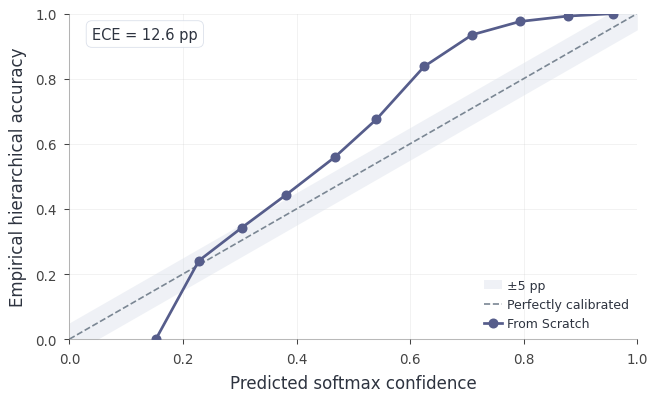

In [4]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_A(ax, max_prob, correct):
    n_bins = 12
    bin_edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(max_prob, bin_edges) - 1, 0, n_bins - 1)
    conf = centers.copy()
    acc = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        m = idx == i
        if m.any():
            conf[i] = max_prob[m].mean(); acc[i] = correct[m].mean()
            counts[i] = int(m.sum())
    valid = counts > 0
    xs = np.linspace(0, 1, 200)
    ax.fill_between(xs, np.clip(xs - 0.05, 0, 1), np.clip(xs + 0.05, 0, 1),
                    color=PAL['light_gray'], alpha=0.4, linewidth=0, zorder=1,
                    label='±5 pp')
    ax.plot([0, 1], [0, 1], color=PAL['gray'], linestyle='--', linewidth=0.8,
            label='Perfectly calibrated', zorder=2)
    ax.plot(conf[valid], acc[valid], marker='o', color=PAL['theme'],
            linewidth=1.3, markersize=3.8, label='From Scratch', zorder=4)
    edges15 = np.linspace(0, 1, 16)
    idx15 = np.clip(np.digitize(max_prob, edges15) - 1, 0, 14)
    n = len(max_prob); ece = 0.0
    for i in range(15):
        m = idx15 == i
        if m.any():
            ece += (m.sum() / n) * abs(correct[m].mean() - max_prob[m].mean())
    ax.text(0.04, 0.96, f'ECE = {ece * 100:.1f} pp', transform=ax.transAxes,
            ha='left', va='top', fontsize=7.0,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=PAL['light_gray'], alpha=0.9))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted softmax confidence')
    ax.set_ylabel('Empirical hierarchical accuracy')
    ax.legend(loc='lower right', fontsize=6.0, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='both')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_A(ax, max_prob, correct)
fig.tight_layout()
plt.show()

## Confidence by correctness — Supp. Fig. 5g

Max-softmax confidence histograms split by hierarchical correctness, with the
**abstention threshold** overlaid (dashed line) — where the kept and abstained
confidence distributions separate.

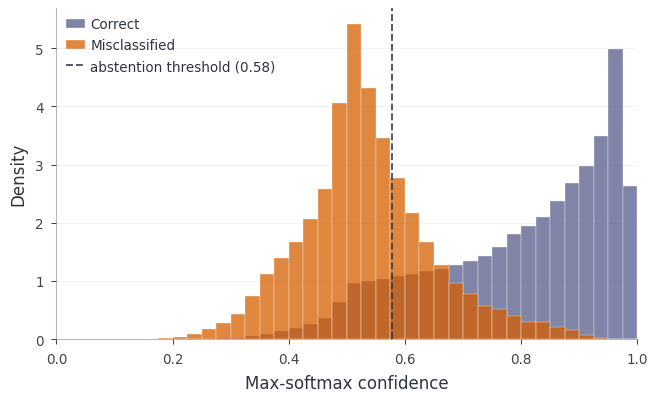

In [5]:
from dct_figures.style import PAL, COL_1_5, style_ax

def _panel_B(ax, max_prob, correct, abstain_threshold):
    bins = np.linspace(0, 1, 41)
    ax.hist(max_prob[correct], bins=bins, color=PAL['theme'], alpha=0.75,
            density=True, edgecolor='white', linewidth=0.2, label='Correct')
    ax.hist(max_prob[~correct], bins=bins, color=PAL['red'], alpha=0.75,
            density=True, edgecolor='white', linewidth=0.2, label='Misclassified')
    ax.axvline(abstain_threshold, color=PAL['dark'], linestyle='--', linewidth=0.9,
               alpha=0.85, zorder=5,
               label=f'abstention threshold ({abstain_threshold:.2f})')
    ax.set_xlabel('Max-softmax confidence'); ax.set_ylabel('Density')
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left', fontsize=6.5, framealpha=0.92,
              handletextpad=0.4, borderaxespad=0.3)
    style_ax(ax, grid_axis='y')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
_panel_B(ax, max_prob, correct, abstain_threshold)
fig.tight_layout()
plt.show()